# Домашнее задание 6. Визуализация данных в Python

**Выполнила**: Смирнова Анастасия (код 100499)

**Домашнее задание состоит из восьми задач, которые вам нужно решить.**

* За каждую выполненную без ошибок задачу вы полные баллы.
* Если задача решена частично или с некритичной ошибкой, вы можете получить до половины баллов.
* За нерешенную или решенную неверно задачу баллы не ставятся.

**Инструкция:** выполните задания в этом же ноутбуке (места под решения каждой задачи обозначаются как **#НАЧАЛО ВАШЕГО РЕШЕНИЯ** и **#КОНЕЦ ВАШЕГО РЕШЕНИЯ**).

**Перед выполнением задания:**
* Перезапустите ядро (restart the kernel): в меню выбрать Ядро (Kernel) → Перезапустить (Restart).
* Выполните все ячейки (run all cells): в меню выбрать Ячейка (Cell) → Запустить все (Run All).


## Введение

Банк обращается к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов, но для этого необходимо выяснить основные причины их оттока. Иными словами, нужно установить, чем ушедшие клиенты отличаются от лояльных и как связаны различные признаки, описывающие клиентов.

После разведывательного анализа, с целью выявления наиболее важных факторов оттока, банк сможет построить модель машинного обучения для прогнозирования ухода клиента.


**Описание столбцов датасета**:

| Название столбца     | Описание                                                                 |
|----------------------|--------------------------------------------------------------------------|
| CustomerId           | Идентификатор клиента                                                    |
| Surname              | Фамилия клиента                                                          |
| CreditScore          | Кредитный рейтинг клиента (чем выше, тем надёжнее клиент)                |
| Geography            | Страна клиента (банк международный)                                      |
| Gender               | Пол клиента                                                              |
| Age                  | Возраст клиента                                                          |
| Tenure               | Сколько лет клиент пользуется услугами банка                             |
| Balance              | Баланс на счетах клиента в банке                                         |
| NumOfProducts        | Количество услуг банка, которые приобрёл клиент                          |
| HasCrCard            | Есть ли у клиента кредитная карта (1 — да, 0 — нет)                      |
| IsActiveMember       | Статус активного клиента (1 — да, 0 — нет)                               |
| EstimatedSalary      | Предполагаемая заработная плата клиента                                  |
| Exited               | Статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)              |

**Советы по выполнению**:
* Для построения графиков используйте библиотеки [Matplotlib](https://matplotlib.org/), [Seaborn](https://seaborn.pydata.org/) или [Plotly](https://plotly.com/python/).
* К каждому заданию обязательно постройте хотя бы один график и запишите выводы, которые можно сделать на его основе.
* Перед началом обязательно определите, какие признаки являются числовыми, а какие категориальными, чтобы правильно выбрать тип визуализации.


In [ ]:
# Ячейка для выгрузки необходимых библиотек
# Дополняйте ее по своим возможностям и потребностям
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Настройки графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

In [ ]:
# Чтение данных
bank_clients = pd.read_csv('bank_clients.csv')

bank_clients.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
1,16,15643966,Goforth,616,Germany,Male,45,3,143129.41,2,0,1,64327.26,0
2,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
3,27,15736816,Young,756,Germany,Male,36,2,136815.64,1,1,1,170041.95,0
4,29,15728693,McWilliams,574,Germany,Female,43,3,141349.43,1,1,1,100187.43,0


# EDA

Начнем с предварительного анализа данных.
Для этого напишем функцию `df_info`, которая выведет основную информацию о датафрейме.

In [ ]:
def df_info(df, df_name=None):
    """
    Выводит информацию о датасете.

    Parameters:
        df (pd.DataFrame): Датафрейм для обработки.
        df_name (str): Название датафрейма (для отображения).
    """

    # Шапка вывода
    print(
        '-' * 10,
        '' * 5,
        f'Информация о датафрейме {str(df_name)}: ',
        '' * 5,
        '-' * 10
    )
    print()

    # 1. Количество строк
    row_count = df.shape[0]  # Возвращаем информацию о количестве строк
    print(f'1) Количество строк: {row_count}')

    # 2. Количество столбцов
    column_count = df.shape[1]  # Возвращаем информацию о количестве столбцов
    print(f'2) Количество столбцов: {column_count}')

    # 3. Типы данных
    columns = df.dtypes  # Возвращаем информацию столбцах и типах данных
    print('3) Типы данных:')
    print()
    print(columns)
    print()

    # 4. Доля пропусков
    is_null = df.isna().mean() * 100  # Возвращаем количество пропусков
    print('4) Доля пропусков в каждом из столбцов:')
    print()
    print(is_null)
    print()

    # 5. Дубликаты
    duplicate_count = df.duplicated().sum()  # Дубликаты
    duplicate_percentage = duplicate_count / len(df) * 100
    print(
        f'5) Полных дубликатов: {duplicate_count} '
        f'({duplicate_percentage:.2f}%)'
    )

In [ ]:
# Применяем функцию
df_info(bank_clients, 'bank_clients')

----------  Информация о датафрейме bank_clients:   ----------

1) Количество строк: 2509
2) Количество столбцов: 14
3) Типы данных:

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

4) Доля пропусков в каждом из столбцов:

RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64

5) Полных дубликатов: 0 (0.00%)


В датафрейме отсутствуют полные дубликаты и пропуски.

Есть один столбец, не заявленный в описании к данным - `RowNumber`. Возможно это столбец с номером строки, который присваивался в базе данных, где хранились данные до выгрузки. Исключим данный столбец из датафрейма.

In [ ]:
# Исключаем столбец row_number
bank_clients = bank_clients.drop(columns='RowNumber')

Первое, что бросается в глаза - наименования столбцов приведены не в соответствии с `snake_case`. Для удобства дальнейшей работы, преобразуем данные.

In [ ]:
def to_snake_case(df):
    """
    Приводит названия столбцов DataFrame к snake_case.

    Параметры:
        df (pd.DataFrame): Исходный DataFrame

    Возвращает:
        pd.DataFrame: DataFrame с преобразованными названиями столбцов
    """
    # Создаем словарь переименования
    new_columns = {}

    for col in df.columns:
        # Приводим к строке
        col_str = str(col)

        # Заменяем пробелы и точки на подчеркивания
        col_str = col_str.replace(' ', '_').replace('.', '_')

        # Вставляем подчеркивание перед заглавными буквами,
        # кроме первого символа и кроме случаев,
        # когда несколько заглавных букв идут подряд
        snake_case = re.sub(r'(?<!^)(?=[A-Z])', '_', col_str).lower()

        # Заменяем множественные подчеркивания на одно
        snake_case = re.sub(r'_+', '_', snake_case)

        # Удаляем подчеркивания в начале и конце
        snake_case = snake_case.strip('_')

        new_columns[col] = snake_case

    # Возвращаем результат
    return df.rename(columns=new_columns)


# Применяем функцию
bank_clients = to_snake_case(bank_clients)

# Проверяем замену наименований
bank_clients.columns

Index(['customer_id', 'surname', 'credit_score', 'geography', 'gender', 'age',
       'tenure', 'balance', 'num_of_products', 'has_cr_card',
       'is_active_member', 'estimated_salary', 'exited'],
      dtype='object')

Переименование выполнено успешно.
Проверим типы данных.

Среди категориальных признаков можно выделить:

- `customer_id`, `has_cr_card`, `age`, `tenure`, `is_active_member`, `exited` - тип `int64`;
- `surname`, `geography`, `gender` - тип `object`.

Типы данных для категориальных признаков `is_active_member`, `exited`, `has_cr_card` могут быть изменены на `bool`, так как данные признаки являются флагами. Проверим, что в данных столбцах встречается только два типа значений и преобразуем к корректному типу.

In [ ]:
# Выводим уникальные значения в каждом из столбцов
print(
    "Уникальные значения в столбце `is_active_member`: "
    f"{bank_clients['is_active_member'].unique()}"
)
print(
    "Уникальные значения в столбце `exited`: "
    f"{bank_clients['exited'].unique()}"
)
print(
    "Уникальные значения в столбце `has_cr_card `: "
    f"{bank_clients['has_cr_card'].unique()}"
)

Уникальные значения в столбце `is_active_member`: [0 1]
Уникальные значения в столбце `exited`: [1 0]
Уникальные значения в столбце `has_cr_card `: [1 0]


В столбцах встречается только два возможных значения: 1 и 0. Это значит, что возможно преобразовать данные столбцы к типу `bool`.

In [ ]:
# Преобразуем типы данных к bool
bank_clients[
    ['is_active_member', 'exited', 'has_cr_card']
] = bank_clients[
    ['is_active_member', 'exited', 'has_cr_card']
].astype('bool')

Преобразуем признаки `geography`, `gender`  к типу данных `category`, так как данные признаки яляются полезными для группировки.

Тип данных для `customer_id` и `surname` оставим без измненений, так как количество возможных вариантов группировки по данным признакам является слишком высоким и не будет информативным.

In [ ]:
# Преобразуем тип данных к category
bank_clients[['geography', 'gender']] = bank_clients[
    ['geography', 'gender']
].astype('category')

Типы данных `age` и `tenure` оставим без изменений.
Количество возможных вариантов группировки для данных признаков также слишком высоко, однако эти признаки могут быть использованы для создания более крупных категориальнеых признаков: возрастных групп и давности использования услуг банков.

In [ ]:
# Проверяем диапазон возрастов
np.sort(bank_clients['age'].unique())

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 81, 83, 84])

Возраст клиентов находится в диапазоне от 18 до 84 лет.
На основании этого выделим несколько групп:

- 18-35 лет - молодые;
- 35-55 лет - средний возраст;
- 55+ - пожилые.

In [ ]:
# Определяем границы для возрастных групп
age_bins = [17, 35, 55, 85]
age_labels = ['молодые', 'средний возраст', 'пожилые']

# Создаем категории
bank_clients['age_group'] = pd.cut(
    bank_clients['age'],
    bins=age_bins,
    labels=age_labels,
    right=False,
    ordered=True
)

In [ ]:
# Проверяем диапазон давности использования услуг банка
np.sort(bank_clients['tenure'].unique())

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

Диапазон давности использования услуг банка составляет 0 - 10 лет.
На основании этого можем выделить три категории:

- Менее года (0 лет);
- От 1 года до 5 лет (1 - 5);
- Более 5 лет (6+).

In [ ]:
# Определяем границы для давности использования банковских услуг
tenure_bins = [-1, 0, 5, 11]
tenure_labels = ['менее года', 'от 1 года до 5 лет', 'более 5 лет']

# Создаем категории
bank_clients['tenure_group'] = pd.cut(
    bank_clients['tenure'],
    bins=tenure_bins,
    labels=tenure_labels,
    right=False,
    ordered=True
)

Проанализируем тип данных числовых признаков:

- `credit_score`, `num_of_products` - тип данных `int64`;
- `balance`, `estimated_salary` - тип данных `float64`.

Типы данных представлены корректно.
Для оптимизации применим понижение разрядности во всех столбцах, где тип данных представлен числами. Для этого применим функцию `downcast`.

In [ ]:
def downcast(df):
    """
    Выполняет понижение разрядности числовых столбцов датафрейма
    с типами int64 и float64 для экономии памяти.
    Преобразует int64 → int8/int16/int32 и float64 → float32.

    Параметры:
        df (pandas.DataFrame): Датафрейм для обработки.

    Возвращает:
        pandas.DataFrame: Обработанный датафрейм с пониженной
        разрядностью числовых столбцов.

    Примечания:
        - Изменяет исходный датафрейм (inplace операция)
        - Выводит информацию о датафрейме после преобразования
    """
    for dtype, column in zip(df.dtypes, df.columns):
        if dtype == 'int64':
            df[column] = pd.to_numeric(df[column], downcast='integer')
        elif dtype == 'float64':
            df[column] = pd.to_numeric(df[column], downcast='float')

    print('Результат понижения разрядности:')
    print()
    return df.info()

In [ ]:
# Применяем функцию downcast()
downcast(bank_clients)

Результат понижения разрядности:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customer_id       2509 non-null   int32   
 1   surname           2509 non-null   object  
 2   credit_score      2509 non-null   int16   
 3   geography         2509 non-null   category
 4   gender            2509 non-null   category
 5   age               2509 non-null   int8    
 6   tenure            2509 non-null   int8    
 7   balance           2509 non-null   float64 
 8   num_of_products   2509 non-null   int8    
 9   has_cr_card       2509 non-null   bool    
 10  is_active_member  2509 non-null   bool    
 11  estimated_salary  2509 non-null   float64 
 12  exited            2509 non-null   bool    
 13  age_group         2509 non-null   category
 14  tenure_group      2509 non-null   category
dtypes: bool(3), category(4), float64(2), i

Понижение разрядности выполнено успешно.

Дополнительно проверим, встречаются ли дубликаты по `customer_id`.

In [ ]:
# Выводим информацию о количестве дубликатов в `customer_id`
customer_duplicates = bank_clients.duplicated(
    subset=['customer_id']
).sum()

print(
    f"Количество дубликатов по `customer_id`: "
    f"{customer_duplicates}"
)

Количество дубликатов по `customer_id`: 0


Все значения в `customer_id` уникальны.

### Вывод

Предварительный анализ данных показал:

- Все записи в таблице `bank_clients` уникальны;
- Пропуски отсуствуют;
- Категориальные признаки - `customer_id`, `surname`, `geography`, `gender`, `age`, `tenure`, `has_cr_card`, `is_active_member`, `exited`;
- Числовые признаки - `creadit_score`, `balance`, `num_of_products`, `estimated_salary`.

Были выполнены следующие преобразования:

- Наименования столбцов приведены в соответствии с snake_case;
- Изменены типы данных на `bool` для столбцов `is_active_member`, `exited`, `has_cr_card`;
- Изменены типы данных на `category` для столбцов `geography`, `gender`;
- Выполнено понижение разрядности в столбцах с числовымм типами даных;
- Добавлены дополнительные категориальные признаки `age_group` (по признаку `age`), `tenure_group` (по признаку `tenure`).

## Задание 1 (12 баллов)
Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

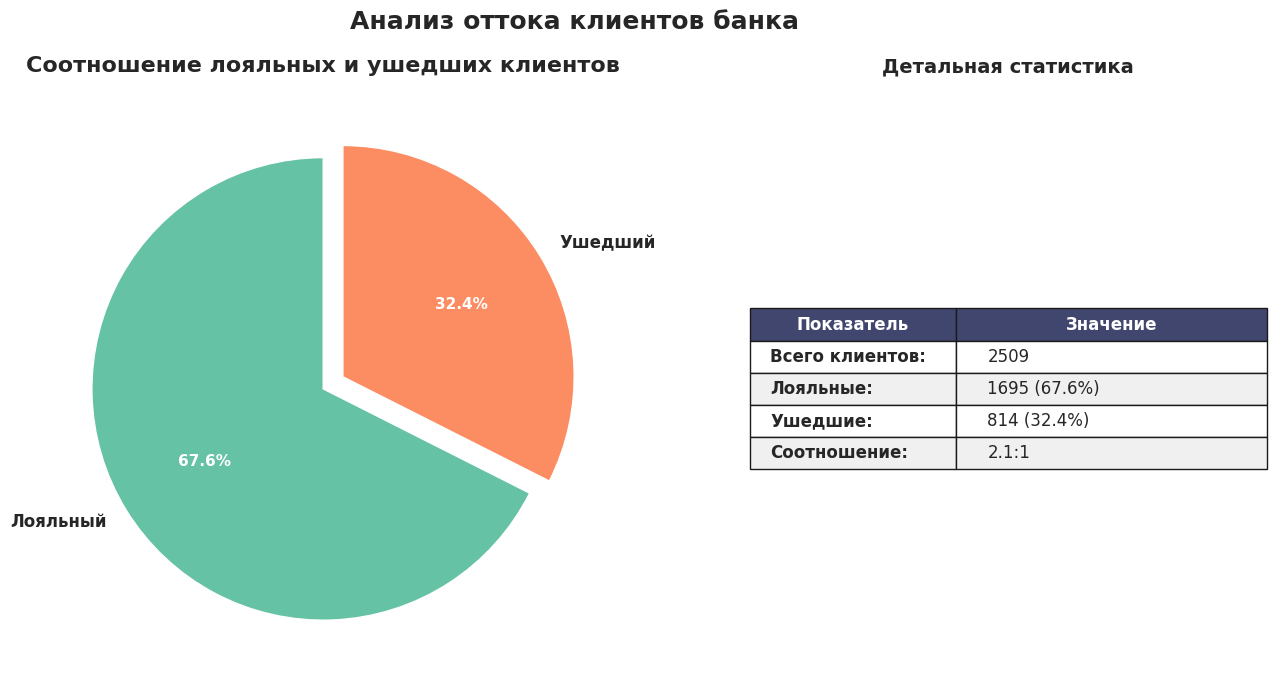

In [ ]:
# НАЧАЛО ВАШЕГО РЕШЕНИЯ

# Агрегируем данные
exited_stats = bank_clients.groupby('exited')[
    'customer_id'
].nunique().reset_index().rename(
    columns={'customer_id': 'Количество клиентов'}
)

# Вычисляем проценты
total = exited_stats['Количество клиентов'].sum()
exited_stats['Процент'] = (
    exited_stats['Количество клиентов'] / total * 100
).round(1)

# Создаем подписи для диаграммы
labels = ['Лояльный', 'Ушедший']

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 7),
    gridspec_kw={'width_ratios': [2, 1]}
)

# Круговая диаграмма
wedges, texts, autotexts = ax1.pie(
    exited_stats['Количество клиентов'],
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66c2a5', '#fc8d62'],
    explode=(0, 0.1),
    textprops={'fontsize': 12}
)

# Настраиваем подписи процентов
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

# Увеличиваем размер подписей категорий
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax1.set_title(
    'Соотношение лояльных и ушедших клиентов',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Создаем таблицу справа с детальной информацией
table_data = exited_stats.copy()
table_data['Статус'] = labels

# Рассчитываем соотношение
loyal_count = exited_stats.iloc[0]['Количество клиентов']
exited_count = exited_stats.iloc[1]['Количество клиентов']
ratio = loyal_count / exited_count

# Подготавливаем данные для таблицы
summary_data = [
    ['Всего клиентов:', f'{total}'],
    [
        'Лояльные:',
        f"{loyal_count} ({exited_stats.iloc[0]['Процент']}%)"
    ],
    [
        'Ушедшие:',
        f"{exited_count} ({exited_stats.iloc[1]['Процент']}%)"
    ],
    ['Соотношение:', f'{ratio:.1f}:1']
]

# Скрываем оси для таблицы
ax2.axis('tight')
ax2.axis('off')

# Создаем таблицу с детальной статистикой
table = ax2.table(
    cellText=summary_data,
    colLabels=['Показатель', 'Значение'],
    cellLoc='left',
    loc='center',
    colWidths=[0.4, 0.6]
)

# Настраиваем таблицу
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Выделяем заголовки таблицы
for i in range(2):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(
        weight='bold',
        color='white',
        fontsize=12
    )

# Заливаем строки для лучшей читаемости
for i in range(1, len(summary_data) + 1):
    if i % 2 == 0:
        for j in range(2):
            table[(i, j)].set_facecolor('#f0f0f0')

# Жирный шрифт для показателей
for i in range(1, len(summary_data) + 1):
    table[(i, 0)].set_text_props(weight='bold')

ax2.set_title(
    'Детальная статистика',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.suptitle(
    'Анализ оттока клиентов банка',
    fontsize=18,
    fontweight='bold',
    horizontalalignment='center',
    y=0.98
)
plt.tight_layout()
plt.show()

# КОНЕЦ ВАШЕГО РЕШЕНИЯ

### Вывод

Лояльных клиентов примерно в два раза больше (67.6%), чем ушедших (32.4%).
Примерно треть клиентов больше не использует услуги банка, что является тревожным сигналом. Необходимо проанализировать их поведение детально, чтобы понять, нет ли в нем закономерностей. Если ушедшие клиенты преимущественно среди тех, кто начал использовать услуги банка недавно, то это значит, что необходимо подумать над мерами по удержанию новых клиентов. Если же отток среди тех клиентов, кто пользовался услугами не один год, то это может говорить о падении общего уровня обслуживания.


## Задание 2 (12 баллов)
Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

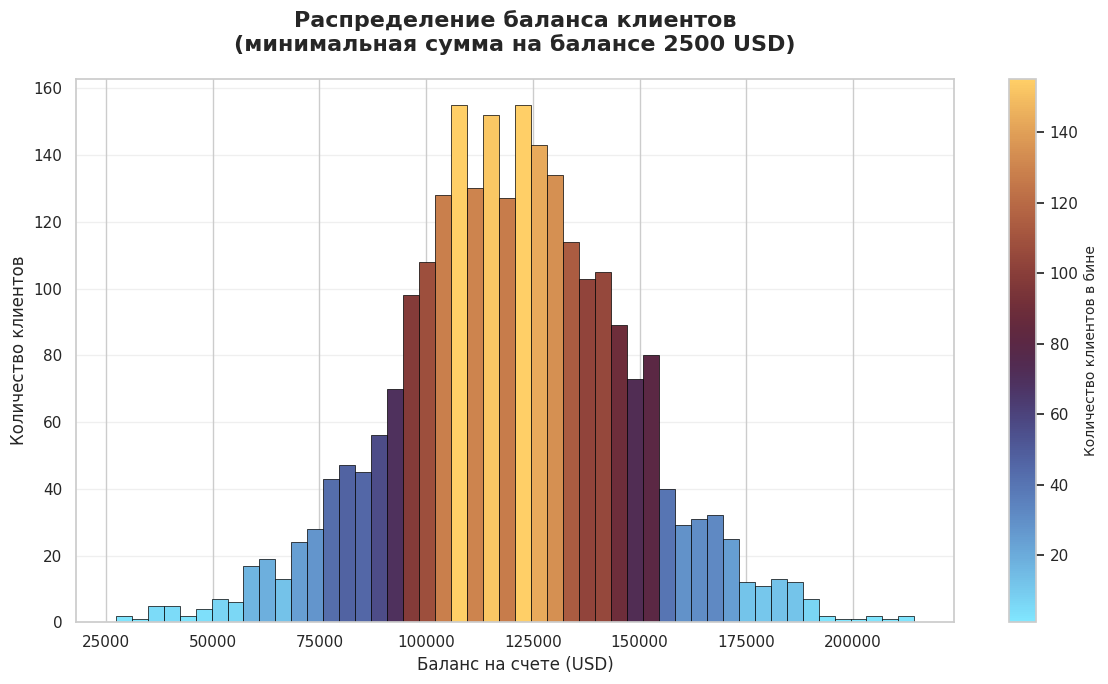

In [ ]:
# НАЧАЛО ВАШЕГО РЕШЕНИЯ

# Фильтруем данные
balance_hist = bank_clients[bank_clients['balance'] > 2500].copy()

# Строим гистограмму
plt.figure(figsize=(12, 7))

# Создаем данные для гистограммы
counts, bins, patches = plt.hist(
    balance_hist['balance'],
    bins=50,
    edgecolor='black',
    linewidth=0.5
)

# Добавляем градиент на основе высоты столбцов
norm = plt.Normalize(counts.min(), counts.max())
cmap = plt.cm.managua_r

for count, patch in zip(counts, patches):
    color = cmap(norm(count))
    patch.set_facecolor(color)

plt.title(
    'Распределение баланса клиентов\n'
    '(минимальная сумма на балансе 2500 USD)',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.xlabel('Баланс на счете (USD)', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Добавляем colorbar для градиента
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Количество клиентов в бине', fontsize=10)

plt.tight_layout()
plt.show()

# КОНЕЦ ВАШЕГО РЕШЕНИЯ

### Вывод

Распределение сумм на балансе клиентов близко к нормальному.
Это говорит о том, что после применения фильтрации в данных (оставлены только суммы более 2500 USD) отсутствуют явные выбросы. Подобное распределение говорит о том, что дополнительных преобразований в данных не требуется и их можно использовать, например, для проведения статистических тестов.

## Задание 3 (12 баллов)

Постройте тепловую карту по корреляционной матрице (Пирсона), сделайте выводы о линейной взаимосвязи между признаками.

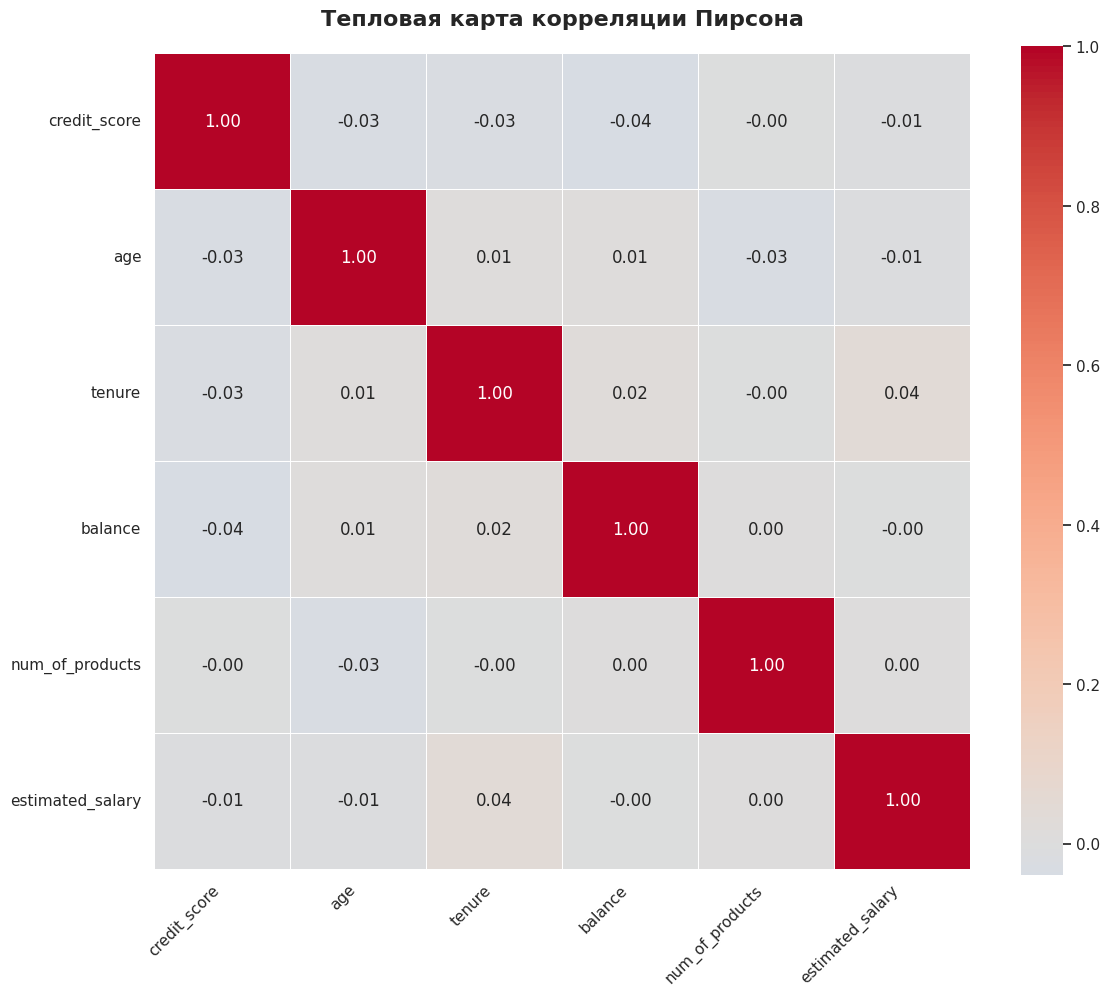

In [ ]:
# НАЧАЛО ВАШЕГО РЕШЕНИЯ

# Выбираем только числовые колонки для корреляции
numeric_cols = bank_clients[[
    'credit_score', 'age', 'tenure', 'balance',
    'num_of_products', 'estimated_salary'
]].columns

# Создаем матрицу корреляции Пирсона
corr_matrix = bank_clients[numeric_cols].corr(method='pearson')

# Создаем фигуру
plt.figure(figsize=(12, 10))

# Создаем тепловую карту
heatmap = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

# Настраиваем заголовок и подписи
plt.title(
    'Тепловая карта корреляции Пирсона',
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# КОНЕЦ ВАШЕГО РЕШЕНИЯ

### Вывод
Матрица корреляции указывает слабую линейную взаимосвязь между признаками, однакот это не является признаком ее полного отсутствия.
Вероятно взаимосвязь носит более сложный характер.

Среди представленных признаков наиболее сильная положительная взаимосвязь наблюдается между давностью использования услуг банка и предполагаемым заработком клиента (0.04). Клиенты с более высоким заработком как правило пользуются услугами банка дольше остальных клиентов.

Среди представленных признаков наиболее сильная отрицательная взаимосвязь между балансом на счете клиента и кредитным рейтингом(-0.04). Это указывает на то, что чем выше баланс клиента, тем меньше его кредитный рейтинг, и наоборот. Таким образом, клиенты, на чьем балансе лежит больше денежных средств реже прибегают к использованию кредитных продуктов и вероятно предпочитают использовать собственные средства.

## Задание 4 (12 баллов)
Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?

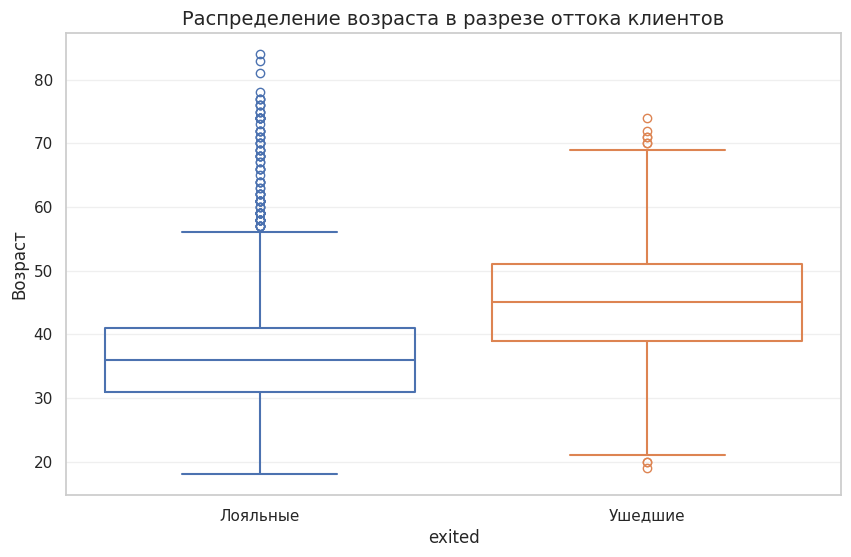

In [ ]:
# НАЧАЛО ВАШЕГО РЕШЕНИЯ

# Строим ящик с усами
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='exited',
    y='age',
    data=bank_clients,
    fill=False,
    legend=False,
    hue='exited',
    showfliers=True
)
plt.title(
    'Распределение возраста в разрезе оттока клиентов',
    fontsize=14
)
plt.ylabel('Возраст', fontsize=12)
plt.xticks([0, 1], ['Лояльные', 'Ушедшие'])
plt.grid(axis='y', alpha=0.3)
plt.show()

# КОНЕЦ ВАШЕГО РЕШЕНИЯ

### Вывод

Распределение возраста  ушедших клиентов более равномерное и содержит меньше выбросов. Среди лояльных клиентов не так много пожилых, поэтому значения их возраста интерпретируются как выбросы.

Медианный возраст ушедших клиентов составляет примерно 45 лет в то время как медианный возраст лояльных клиентов составляет примерно 35 лет.

Распределение возраста ушедших клиентов указывает на то, что услугами банка в основном перестают пользоваться люди в возрасте от 40 до 50 лет. Данная группа клиентов может потенциально иметь наибольший заработок, так как имеет один из самых высоких трудовых стажей среди работающего населения, а также более активно пользоваться кредитными продуктами (ипотека, кредит на авто). Необходимо детально проанализировать причины оттока данной группы клиентов, поскольку банк потенциально упускает выгоду от их обслуживания.

## Задание 5 (13 баллов)
Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Есть ли взаимосвязь между признаками?

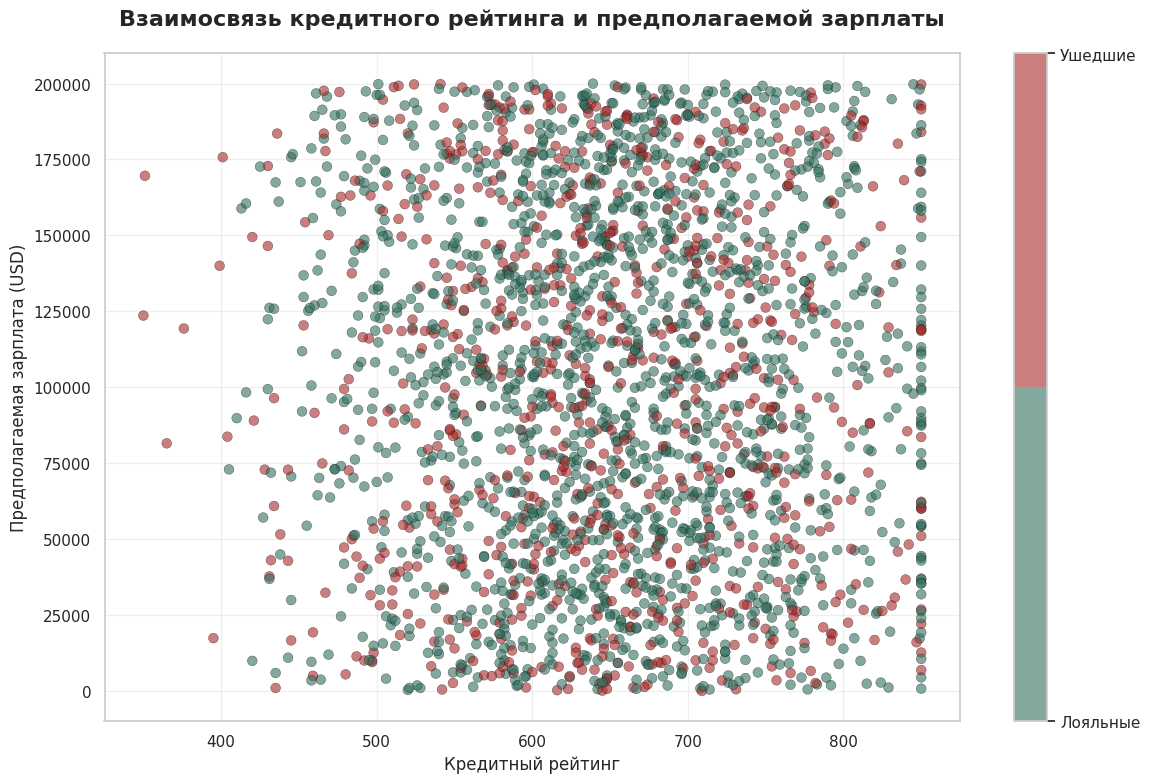

In [ ]:
# НАЧАЛО ВАШЕГО РЕШЕНИЯ

plt.figure(figsize=(12, 8))

# Создаем цветовую карту для двух цветов
custom_cmap = mcolors.ListedColormap(['#31705f', '#a72929'])

# Создаем scatter plot с цветом по оттоку
scatter = plt.scatter(
    x=bank_clients['credit_score'],
    y=bank_clients['estimated_salary'],
    c=bank_clients['exited'],
    cmap=custom_cmap,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.3,
    s=50
)

plt.title(
    'Взаимосвязь кредитного рейтинга и предполагаемой зарплаты',
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.xlabel('Кредитный рейтинг', fontsize=12)
plt.ylabel('Предполагаемая зарплата (USD)', fontsize=12)

# Добавляем colorbar для легенды
cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Лояльные', 'Ушедшие'])

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# КОНЕЦ ВАШЕГО РЕШЕНИЯ

### Вывод:

Диаграмма показывает отсутствие явной зависимости между крединтным рейтингом и предполагаемой зарплатой, как для лояльных, так и для ушедших клиентов.

Большинство клиентов банка имеют кредитный рейтинг от 500 до 800. При этом наблюдается значительный разброс значений предполагаемой заработной платы. Это указывает на то, что среди клиентов с различным уровнем дохода могут встречаться как добросовестные, так и менее добросовестные заемщики.

## Задание 6 (13 баллов)
Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

*Подсказка: процент ушедших клиентов в каждой группе можно рассчитать как среднее по столбцу Exited (так как 1 — это ушедшие клиенты, а 0 — лояльные, среднее арифметическое по столбцу обозначает долю ушедших клиентов).*

/tmp/ipython-input-3883641083.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exited_gender_stats = bank_clients.groupby('gender').agg({


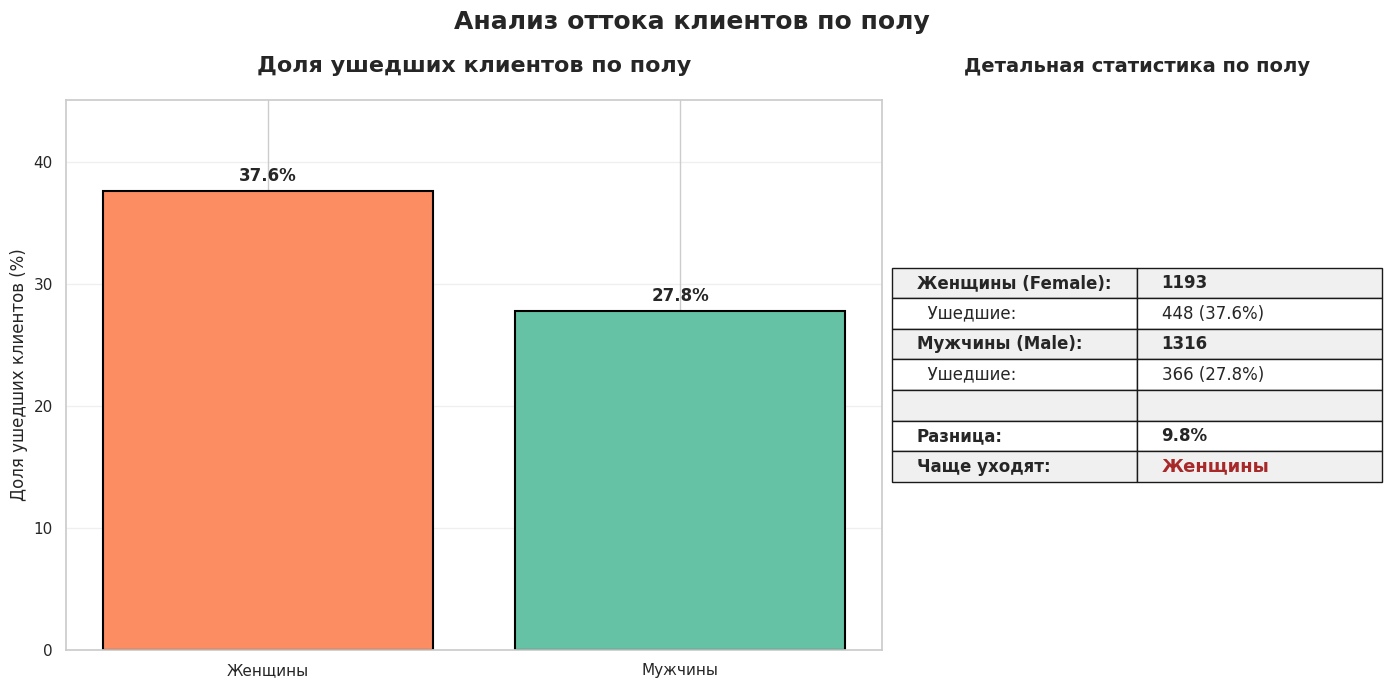

In [ ]:
# НАЧАЛО ВАШЕГО РЕШЕНИЯ

# Агрегируем данные
exited_gender_stats = bank_clients.groupby('gender').agg({
    'customer_id': 'count',
    'exited': 'mean'
}).reset_index().rename(
    columns={
        'customer_id': 'Количество клиентов',
        'exited': 'Доля ушедших',
        'gender': 'Пол'
    }
)

# Сортируем
gender_order = {'Female': 0, 'Male': 1}
exited_gender_stats['gender_order'] = exited_gender_stats['Пол'].map(gender_order)
exited_gender_stats = exited_gender_stats.sort_values('gender_order')

# Вычисляем проценты
exited_gender_stats['Доля ушедших %'] = (
    exited_gender_stats['Доля ушедших'] * 100
).round(1)

# Вычисляем количество ушедших клиентов по полу
exited_gender_stats['Ушедшие клиенты'] = (
    exited_gender_stats['Количество клиентов']
    * exited_gender_stats['Доля ушедших']
).astype(int)

# Создаем подписи для диаграммы
labels = ['Женщины', 'Мужчины']

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 7),
    gridspec_kw={'width_ratios': [2, 1]}
)

# Строим столбчатую диаграмму
bars = ax1.bar(
    labels,
    exited_gender_stats['Доля ушедших %'],
    color=['#fc8d62', '#66c2a5'],  # Оранжевый для женщин, зеленый для мужчин
    edgecolor='black',
    linewidth=1.5
)

# Добавляем подписи значений над столбцами
for i, (bar, value) in enumerate(
    zip(bars, exited_gender_stats['Доля ушедших %'])
):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{value}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Настраиваем первую диаграмму
ax1.set_title(
    'Доля ушедших клиентов по полу',
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax1.set_ylabel('Доля ушедших клиентов (%)', fontsize=12)
ax1.set_ylim(0, exited_gender_stats['Доля ушедших %'].max() * 1.2)
ax1.grid(axis='y', alpha=0.3)

# Создаем таблицу справа с правильными данными
table_data = [
    [
        'Женщины (Female):',
        f"{exited_gender_stats.iloc[0]['Количество клиентов']}"
    ],
    [
        '  Ушедшие:',
        f"{exited_gender_stats.iloc[0]['Ушедшие клиенты']} "
        f"({exited_gender_stats.iloc[0]['Доля ушедших %']}%)"
    ],
    [
        'Мужчины (Male):',
        f"{exited_gender_stats.iloc[1]['Количество клиентов']}"
    ],
    [
        '  Ушедшие:',
        f"{exited_gender_stats.iloc[1]['Ушедшие клиенты']} "
        f"({exited_gender_stats.iloc[1]['Доля ушедших %']}%)"
    ],
    ['', ''],
    [
        'Разница:',
        f"{exited_gender_stats.iloc[0]['Доля ушедших %'] - exited_gender_stats.iloc[1]['Доля ушедших %']:.1f}%"  # 37.6 - 27.8 = 9.8%
    ],
    [
        'Чаще уходят:',
        'Женщины'  # Потому что 37.6% > 27.8%
    ]
]

# Скрываем оси для таблицы
ax2.axis('tight')
ax2.axis('off')

# Создаем таблицу с детальной статистикой
table = ax2.table(
    cellText=table_data,
    cellLoc='left',
    loc='center',
    colWidths=[0.5, 0.5]
)

# Настраиваем таблицу
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Выделяем важные строки
for i in [0, 2, 5, 6]:
    for j in range(2):
        table[(i, j)].set_text_props(weight='bold')

# Заливаем строки для лучшей читаемости
for i in range(len(table_data)):
    if i % 2 == 0:
        for j in range(2):
            table[(i, j)].set_facecolor('#f0f0f0')

# Выделение ячейки "Чаще уходят"
table[(6, 1)].set_text_props(color='#a72929', weight='bold', fontsize=13)

ax2.set_title(
    'Детальная статистика по полу',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.suptitle(
    'Анализ оттока клиентов по полу',
    fontsize=18,
    fontweight='bold',
    horizontalalignment='center',
    y=0.98
)
plt.tight_layout()
plt.show()

# КОНЕЦ ВАШЕГО РЕШЕНИЯ

### Вывод:

Среди клиентов банка больше мужчин.
При этом доля ушедших клиентов среди мужчин на 9,8% ниже, чем среди женщин.

Таким образом, мужчины являются более лояльными клиентами.

## Задание 7 (13 баллов)
Как отток клиентов зависит от числа приобретенных у банка услуг? Для ответа на этот вопрос используйте столбчатую диаграмму.

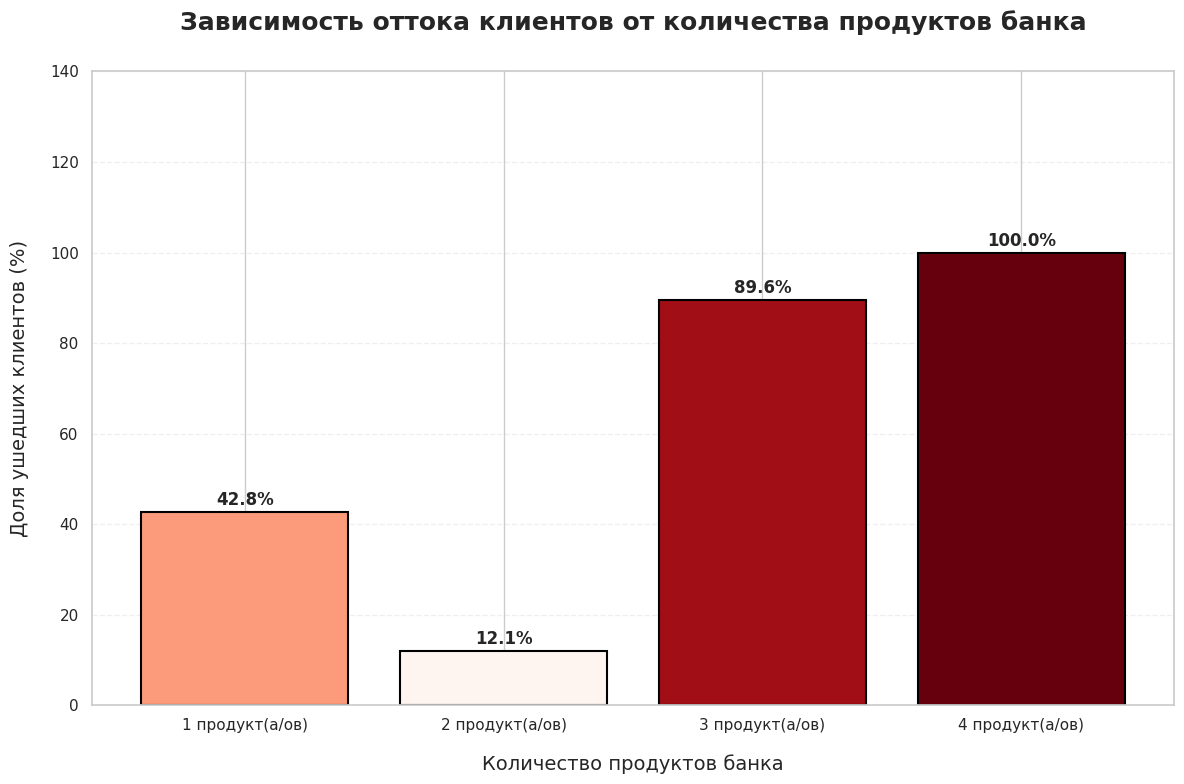

In [ ]:
# НАЧАЛО ВАШЕГО РЕШЕНИЯ

# Агрегируем данные - считаем долю ушедших для каждого количества продуктов
exited_num_of_products_stats = bank_clients.groupby('num_of_products').agg({
    'customer_id': 'count',
    'exited': 'mean'
}).reset_index().rename(
    columns={
        'customer_id': 'Количество клиентов',
        'exited': 'Доля ушедших',
        'num_of_products': 'Количество продуктов'
    }
)

# Сортируем по количеству продуктов
exited_num_of_products_stats = exited_num_of_products_stats.sort_values('Количество продуктов')

# Вычисляем проценты
exited_num_of_products_stats['Доля ушедших %'] = (
    exited_num_of_products_stats['Доля ушедших'] * 100
).round(1)

# Вычисляем количество ушедших клиентов по количеству продуктов
exited_num_of_products_stats['Ушедшие клиенты'] = (
    exited_num_of_products_stats['Количество клиентов']
    * exited_num_of_products_stats['Доля ушедших']
).astype(int)

# Создаем подписи для диаграммы
labels = [f'{int(x)} продукт(а/ов)' for x in exited_num_of_products_stats['Количество продуктов']]

# Создаем фигуру
plt.figure(figsize=(12, 8))

# Цвета для столбцов
exit_percentages = exited_num_of_products_stats['Доля ушедших %']
norm = plt.Normalize(exit_percentages.min(), exit_percentages.max())
colors = plt.cm.Reds(norm(exit_percentages))  # Градиент от светлого к темно-красному

# Строим столбчатую диаграмму
bars = plt.bar(
    labels,
    exited_num_of_products_stats['Доля ушедших %'],
    color=colors,
    edgecolor='black',
    linewidth=1.5,
)

# Добавляем подписи значений над столбцами
for i, (bar, value, total_clients, exited_clients) in enumerate(zip(
    bars,
    exited_num_of_products_stats['Доля ушедших %'],
    exited_num_of_products_stats['Количество клиентов'],
    exited_num_of_products_stats['Ушедшие клиенты']
)):
    height = bar.get_height()
    # Подпись процента
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{value}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Настраиваем диаграмму
plt.title(
    'Зависимость оттока клиентов от количества продуктов банка',
    fontsize=18,
    fontweight='bold',
    pad=30
)
plt.xlabel('Количество продуктов банка', fontsize=14, labelpad=15)
plt.ylabel('Доля ушедших клиентов (%)', fontsize=14, labelpad=15)

# Настраиваем ось Y
plt.ylim(0, exited_num_of_products_stats['Доля ушедших %'].max() * 1.4)

# Добавляем сетку
plt.grid(axis='y', alpha=0.3, linestyle='--')


plt.tight_layout()
plt.show()

# КОНЕЦ ВАШЕГО РЕШЕНИЯ

## Вывод

Среди клиентов, у которых четыре продукта в использовании доля оттока составляет 100%.
На втором месте расположились клиенты с тремя продуктами в использовании (доля оттока 89,6%).
Далее следуют клиенты с одним продуктом в использовании (42,8%).

Среди клиентов, использующих два продукта, доля оттока самая низкая. Это говорит о том, что среди данной группы клиентов удовлетворенность предоставляемыми услугами наивысшая.

Некоторые клиенты уходят из банка открыв только один продукт, другие же пробуют остальные продукты и в конечно итоге уходят, так и не найдя подходящий для себя.

## Задание 8 (13 баллов)

Постройте сводную таблицу, где по строкам будет пол (`Gender`), по столбцам — число приобретенных услуг (`NumOfProducts`), а в ячейках — суммарное число ушедших клиентов в этой группе (`Exited`). Затем визуализируйте эту таблицу с помощью тепловой карты и сделайте выводы.

/tmp/ipython-input-2490143671.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  num_of_product_pivot = bank_clients.pivot_table(index='gender',


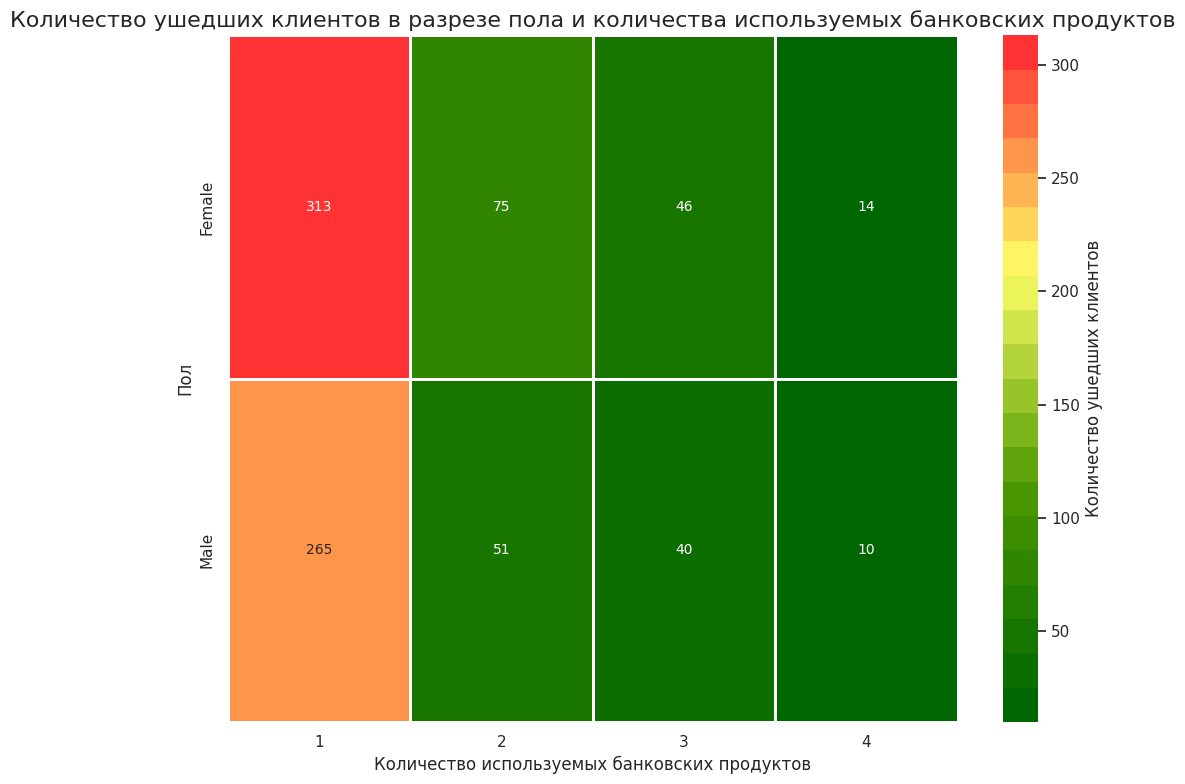

In [ ]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ

# Агрегируем данные
num_of_product_pivot = bank_clients.pivot_table(index='gender',
                                                columns='num_of_products',
                                                values='exited',
                                                aggfunc='sum')

# Создаем цветовую карту
cmap = mcolors.LinearSegmentedColormap.from_list('green_red',
                                                ['#006600', '#4C9900', '#FFFF66', '#FF3333'],
                                                N=20)

# Строим heatmap
plt.figure(figsize=(10,8))

sns.heatmap(num_of_product_pivot,
            cmap=cmap,
            annot=True,
            fmt=',.0f',
            linewidths=2,
            annot_kws={"size": 10},
            cbar_kws={'label': 'Количество ушедших клиентов'})

plt.title('Количество ушедших клиентов в разрезе пола и количества используемых банковских продуктов', fontsize=16)
plt.xlabel('Количество используемых банковских продуктов')
plt.ylabel('Пол')
plt.tight_layout()
plt.show()

#КОНЕЦ ВАШЕГО РЕШЕНИЯ

### Вывод

Большинство ушедших клиентов имели в использовании только один продукт. Это справедливо как для мужчин, так и для женщин.

Меньше всего ушедших клиентов в группе с четырьмя используемыми продуктами.
Количество клиентов в каждой группе уменьшается по мере роста количества продуктов в использовании.